<a href="https://colab.research.google.com/github/shreyarani62021-crypto/Titanic-Survival-Analysis-Python/blob/main/CodeAlpha_Data_Analytics_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== 1. DATASET OVERVIEW ===
Total Rows: 418, Total Columns: 5

=== 2. DATA TYPES & MISSING VALUES ===
Survived     0
Pclass       0
Sex          0
Age         86
Fare         1
dtype: int64

=== 3. SUMMARY STATISTICS ===
         Survived      Pclass         Age        Fare
count  418.000000  418.000000  332.000000  417.000000
mean     0.363636    2.265550   30.272590   35.627188
std      0.481622    0.841838   14.181209   55.907576
min      0.000000    1.000000    0.170000    0.000000
25%      0.000000    1.000000   21.000000    7.895800
50%      0.000000    3.000000   27.000000   14.454200
75%      1.000000    3.000000   39.000000   31.500000
max      1.000000    3.000000   76.000000  512.329200

=== 4. SURVIVAL RATE BY GENDER ===
Sex
female    100.0
male        0.0
Name: Survived, dtype: float64

=== 5. SURVIVAL RATE BY PASSENGER CLASS ===
Pclass
1    46.728972
2    32.258065
3    33.027523
Name: Survived, dtype: float64


/tmp/ipykernel_3327/591956099.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_3327/591956099.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

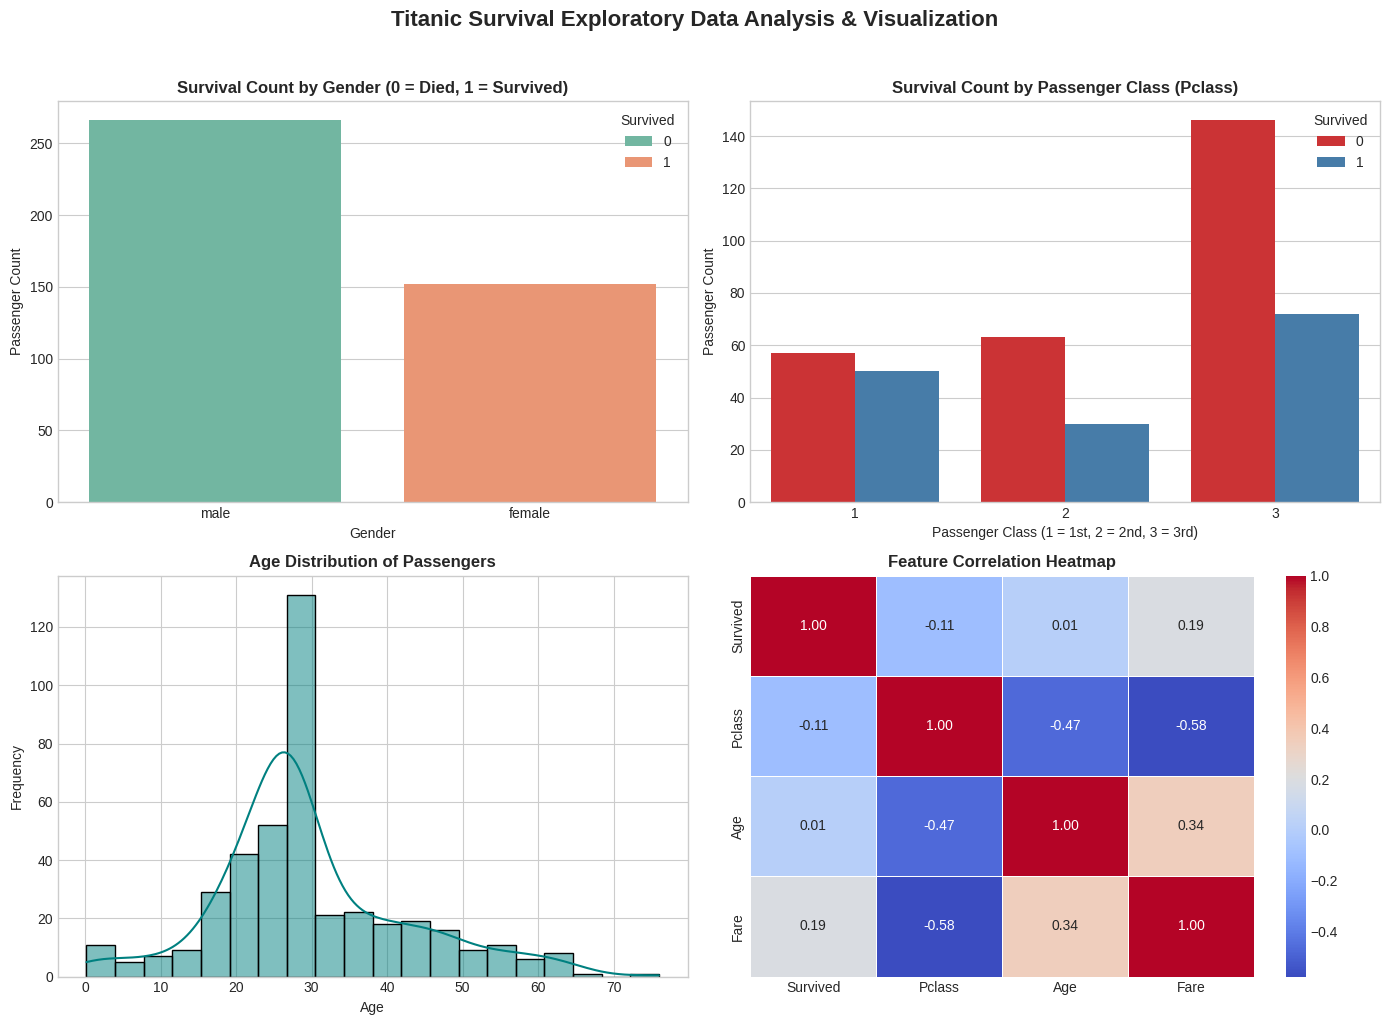

In [ ]:
# ==========================================
# TITANIC SURVIVAL: TASK 2 & TASK 3
# Project: Titanic Survival Data Analysis & Visualization
# Tech Stack: Python, Pandas, Seaborn, Matplotlib
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATASET
df = pd.read_csv('titanic_survival.csv')

# ------------------------------------------
# TASK 2: EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------------------
print("=== 1. DATASET OVERVIEW ===")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}\n")

print("=== 2. DATA TYPES & MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== 3. SUMMARY STATISTICS ===")
print(df.describe())

# Data Cleaning: Handle Missing Values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)

print("\n=== 4. SURVIVAL RATE BY GENDER ===")
print(df.groupby('Sex')['Survived'].mean() * 100)

print("\n=== 5. SURVIVAL RATE BY PASSENGER CLASS ===")
print(df.groupby('Pclass')['Survived'].mean() * 100)


# ------------------------------------------
# TASK 3: DATA VISUALIZATION
# ------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Survival Count by Gender
sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Survival Count by Gender (0 = Died, 1 = Survived)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Passenger Count')

# Chart 2: Survival Rate by Passenger Class
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Survival Count by Passenger Class (Pclass)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
axes[0, 1].set_ylabel('Passenger Count')

# Chart 3: Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[1, 0], color='teal', bins=20)
axes[1, 0].set_title('Age Distribution of Passengers', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Frequency')

# Chart 4: Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[1, 1], fmt='.2f', linewidths=0.5)
axes[1, 1].set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')

plt.suptitle('Titanic Survival Exploratory Data Analysis & Visualization', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()